In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE

In [4]:
df = pd.read_csv('ai4i2020.csv')
df.columns = [c.strip() for c in df.columns]  # 원본 컬럼명에 앞뒤 공백이 섞여있음 (예: ' Product ID')

In [5]:
# Product ID 제거
df = df.drop(columns=["Product ID"])

# Type One-Hot Encoding
df = pd.get_dummies(df, columns=["Type"], drop_first=True)

# X, y 분리
X = df.drop(columns=[
    "Machine failure",
    "TWF",
    "HDF",
    "PWF",
    "OSF",
    "RNF"
])

y = df["Machine failure"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=49,
    stratify=y
)

scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

sm = SMOTE(random_state=42)

X_train_sm, y_train_sm = sm.fit_resample(
    X_train,
    y_train
)

Random Forest
Accuracy : 0.942

              precision    recall  f1-score   support

           0       0.99      0.95      0.97      1932
           1       0.35      0.85      0.50        68

    accuracy                           0.94      2000
   macro avg       0.67      0.90      0.73      2000
weighted avg       0.97      0.94      0.95      2000



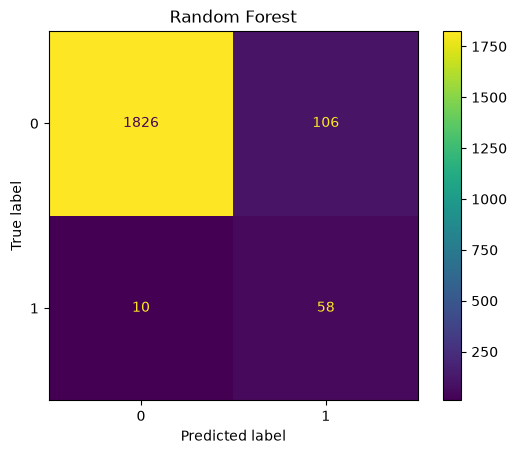

In [7]:
rf=RandomForestClassifier(
    n_estimators=500,
    max_depth=15,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42

) # 모델 만듦, balanced-> 고장 데이터가 적으니 고장데이터 가중치 높임

# rf.fit(X_train, y_train) # 학습
rf.fit(
    X_train_sm,
    y_train_sm
)

# rf_pred = rf.predict(X_test) # 예측

proba = rf.predict_proba(X_test)

rf_pred = (proba[:,1] > 0.3).astype(int)


print("="*50)
print("Random Forest")
print("="*50)

print("Accuracy :", accuracy_score(y_test, rf_pred)) # 정확도 뽑기
print()

print(classification_report(y_test, rf_pred))

ConfusionMatrixDisplay.from_predictions(y_test, rf_pred)
plt.title("Random Forest")
plt.show()

XGBoost
Accuracy : 0.984
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.91      0.59      0.71        68

    accuracy                           0.98      2000
   macro avg       0.95      0.79      0.85      2000
weighted avg       0.98      0.98      0.98      2000



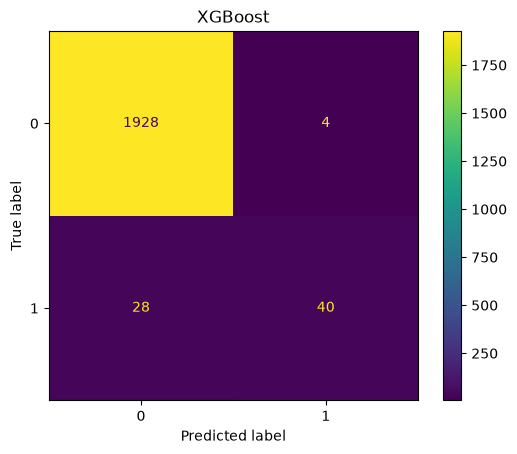

In [8]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

print("="*50)
print("XGBoost")
print("="*50)

print("Accuracy :", accuracy_score(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred))

ConfusionMatrixDisplay.from_predictions(y_test, xgb_pred)
plt.title("XGBoost")
plt.show()

[LightGBM] [Info] Number of positive: 271, number of negative: 7729
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000901 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1182
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.033875 -> initscore=-3.350616
[LightGBM] [Info] Start training from score -3.350616
LightGBM
Accuracy : 0.9845
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.89      0.62      0.73        68

    accuracy                           0.98      2000
   macro avg       0.94      0.81      0.86      2000
weighted avg       0.98      0.98      0.98      2000



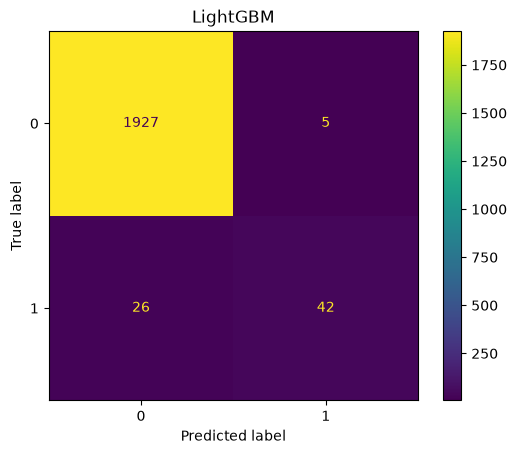

In [9]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    random_state=42,
    n_estimators=300
)

lgbm.fit(X_train, y_train)

lgbm_pred = lgbm.predict(X_test)

print("="*50)
print("LightGBM")
print("="*50)

print("Accuracy :", accuracy_score(y_test, lgbm_pred))
print(classification_report(y_test, lgbm_pred))

ConfusionMatrixDisplay.from_predictions(y_test, lgbm_pred)
plt.title("LightGBM")
plt.show()